### 1. Import thư viện và cấu hình môi trường

Phần này import các thư viện cần thiết cho toàn bộ pipeline bao gồm xử lý dữ liệu, trực quan hóa, huấn luyện mô hình và đánh giá kết quả. Đồng thời thiết lập giá trị random seed nhằm đảm bảo tính tái lập (reproducibility) của kết quả, đúng theo yêu cầu của bài thi.

In [1]:
# CEll 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 2. Đọc dữ liệu đầu vào

Phần này đọc các file dữ liệu chính bao gồm dữ liệu doanh thu lịch sử (sales), file mẫu submission, dữ liệu lưu lượng truy cập (web traffic) và dữ liệu tồn kho (inventory).

Cột Date được chuyển sang định dạng datetime để phục vụ việc tạo các đặc trưng theo thời gian.

Lưu ý: file sample_submission chỉ được sử dụng để lấy khung ngày (Date). Các giá trị Revenue và COGS trong file này không được sử dụng vì đây là biến mục tiêu cần dự báo.

In [2]:
# Cell 2
import pandas as pd

def load_data(path="dataset/"):
    data = {}
    
    files = [
        "sales.csv",
        "orders.csv",
        "order_items.csv",
        "payments.csv",
        "shipments.csv",
        "returns.csv",
        "reviews.csv",
        "customers.csv",
        "products.csv",
        "geography.csv",
        "web_traffic.csv",
        "inventory.csv",
        "promotions.csv",
        "sample_submission.csv",
    ]
    
    for f in files:
        name = f.replace(".csv", "")
        df = pd.read_csv(path + f)
        df.columns = df.columns.str.strip().str.lower()
        data[name] = df
    
    return data
DATA = load_data()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24840\3555844419.py:26: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + f)


In [3]:
# Cell 3
sales = pd.read_csv("sales.csv", parse_dates=["Date"])

# Chỉ lấy Date từ sample, bỏ Revenue/COGS để tránh nhầm với prediction có sẵn
sample = pd.read_csv("sample_submission.csv", usecols=["Date"], parse_dates=["Date"])

traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])
inventory = pd.read_csv("inventory.csv", parse_dates=["snapshot_date"])

print(sales.shape)
print(sample.shape)
print(traffic.shape)
print(inventory.shape)

sales.head()

(3833, 3)
(548, 1)
(3652, 7)
(60247, 17)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


### 3. Kiểm tra cấu trúc dữ liệu ban đầu

Mục tiêu của bước này là hiểu sơ bộ dữ liệu trước khi xây dựng mô hình. Các thao tác bao gồm:
- Kiểm tra số dòng, số cột
- Kiểm tra kiểu dữ liệu từng cột
- Xem một vài dòng đầu

Việc này giúp phát hiện sớm các vấn đề như sai định dạng ngày, thiếu dữ liệu hoặc kiểu dữ liệu không phù hợp.





In [4]:
# Cell 4
print(sales.info())
print(sales.describe())
print(sales.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 90.0 KB
None
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06
Date       0
Revenue    0
COGS       0
dtype: int64


### 4. Quan sát chuỗi thời gian Revenue

Biểu đồ này thể hiện doanh thu theo thời gian từ năm 2012 đến 2022. Đây là bước quan trọng để:
- Nhận diện xu hướng tăng trưởng dài hạn
- Quan sát tính mùa vụ (seasonality)
- Phát hiện các điểm bất thường (spike)

Những đặc điểm này sẽ định hướng cách xây dựng feature và mô hình dự báo.

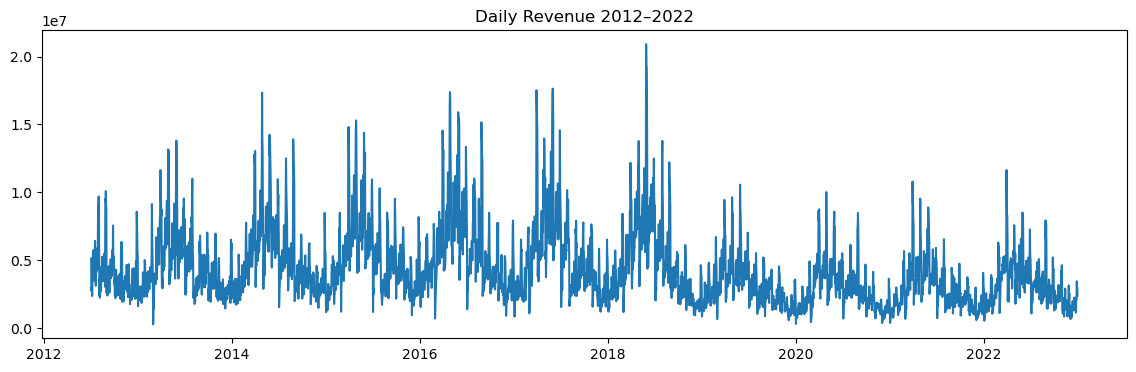

In [5]:
# Cell 5
plt.figure(figsize=(14,4))
plt.plot(sales["Date"], sales["Revenue"])
plt.title("Daily Revenue 2012–2022")
plt.show()

### 5. Tạo đặc trưng thời gian nâng cao (advanced calendar features)

Ngoài các đặc trưng thời gian cơ bản, bước này bổ sung thêm các đặc trưng nâng cao nhằm giúp mô hình học tốt hơn tính chu kỳ của dữ liệu.

Cụ thể:
- week_of_year: xác định vị trí tuần trong năm
- is_month_start, is_month_end: đánh dấu đầu và cuối tháng
- cyclical encoding (sin, cos): biểu diễn tính chu kỳ của month, day_of_week và day_of_year

Việc sử dụng sin/cos giúp mô hình hiểu rằng các giá trị như tháng 12 và tháng 1 có tính liên tục, thay vì bị xem là xa nhau về mặt số học.

In [6]:
# Cell 6
def add_calendar_features(df):
    df = df.copy()
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["quarter"] = df["Date"].dt.quarter
    df["day_of_year"] = df["Date"].dt.dayofyear
    df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

    # Cyclical encoding: giúp model hiểu tháng/ngày trong tuần có tính chu kỳ
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

    return df

sales = add_calendar_features(sales)
sample = add_calendar_features(sample)

### 6. Tổng hợp dữ liệu web traffic theo ngày

Dữ liệu web traffic ban đầu có nhiều dòng cho mỗi ngày (theo từng nguồn traffic). Do đó cần tổng hợp lại theo ngày để phù hợp với dữ liệu doanh thu.

Các biến số lượng như sessions, unique visitors, page views được cộng lại theo ngày, trong khi các biến tỷ lệ như bounce rate và thời gian phiên được lấy trung bình.
Việc phân biệt cách tổng hợp giúp đảm bảo tính đúng đắn của dữ liệu sau khi aggregate.

Các biến này đóng vai trò là tín hiệu nhu cầu (demand signal) vì lượng truy cập website thường liên quan trực tiếp đến doanh thu.

In [7]:
# Cell 7
traffic_daily = (
    traffic
    .groupby("date")
    .agg({
        "sessions": "sum",
        "unique_visitors": "sum",
        "page_views": "sum",
        "bounce_rate": "mean",
        "avg_session_duration_sec": "mean"
    })
    .reset_index()
    .rename(columns={"date": "Date"})
)

sales = sales.merge(traffic_daily, on="Date", how="left")
sample = sample.merge(traffic_daily, on="Date", how="left")

### 7. Kết hợp dữ liệu web traffic vào tập train và test

Dữ liệu traffic được join vào bảng chính theo cột Date. Sử dụng left join để đảm bảo không mất ngày nào trong tập dữ liệu.

Đối với các ngày trong tương lai (test) chưa có traffic thực tế, giá trị được ước lượng bằng trung bình lịch sử theo tháng và ngày. Điều này giúp tránh sử dụng dữ liệu ngoài nhưng vẫn giữ được pattern mùa vụ.

In [8]:
# Cell 8 
traffic_cols = [
    "sessions",
    "unique_visitors",
    "page_views",
    "bounce_rate",
    "avg_session_duration_sec"
]

traffic_pattern = (
    sales
    .groupby(["month", "day"])[traffic_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in traffic_cols if c in sample.columns])
sample = sample.merge(traffic_pattern, on=["month", "day"], how="left")

for col in traffic_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

### 7.1. Tạo đặc trưng mở rộng từ web traffic

Bước này tạo thêm các đặc trưng tổng hợp từ dữ liệu web traffic nhằm phản ánh chất lượng và hành vi người dùng.

Các đặc trưng bao gồm:
- pageviews_per_session: số trang trung bình mỗi phiên
- sessions_per_visitor: mức độ quay lại của người dùng
- traffic_engagement: mức độ tương tác tổng hợp
- bounce_sessions: số phiên thoát nhanh

Những biến này giúp mô hình hiểu sâu hơn về hành vi người dùng, không chỉ số lượng truy cập.

In [9]:
# Cell 9
def add_traffic_derived_features(df):
    df = df.copy()
    df["pageviews_per_session"] = df["page_views"] / (df["sessions"] + 1)
    df["sessions_per_visitor"] = df["sessions"] / (df["unique_visitors"] + 1)
    df["traffic_engagement"] = df["pageviews_per_session"] * df["avg_session_duration_sec"]
    df["bounce_sessions"] = df["bounce_rate"] * df["sessions"]
    return df

sales = add_traffic_derived_features(sales)
sample = add_traffic_derived_features(sample)

### 8. Tổng hợp dữ liệu tồn kho theo tháng

Dữ liệu inventory được ghi nhận theo tháng và theo từng sản phẩm. Cần tổng hợp lại theo tháng để có thể gắn vào dữ liệu doanh thu theo ngày.

Các biến như tồn kho, số ngày hết hàng, fill rate phản ánh khả năng cung ứng sản phẩm, từ đó ảnh hưởng trực tiếp đến doanh thu.

In [10]:
# Cell 10
inventory["year"] = inventory["snapshot_date"].dt.year
inventory["month"] = inventory["snapshot_date"].dt.month

inventory_monthly = (
    inventory
    .groupby(["year", "month"])
    .agg({
        "stock_on_hand": "sum",
        "units_received": "sum",
        "units_sold": "sum",
        "stockout_days": "sum",
        "days_of_supply": "mean",
        "fill_rate": "mean",
        "stockout_flag": "max",
        "overstock_flag": "max",
        "reorder_flag": "max",
        "sell_through_rate": "mean"
    })
    .reset_index()
)

sales = sales.merge(inventory_monthly, on=["year", "month"], how="left")
sample = sample.merge(inventory_monthly, on=["year", "month"], how="left")

### 9. Kết hợp dữ liệu tồn kho vào tập train và test

Dữ liệu inventory được join theo year và month. Điều này giúp mỗi ngày trong tháng có thông tin về tình trạng tồn kho.

Đối với tập test, khi không có dữ liệu tồn kho tương lai, các giá trị được điền bằng trung bình lịch sử theo tháng. Cách này giúp mô hình vẫn có thông tin supply mà không vi phạm quy định.

In [11]:
# Cell 11
inventory_cols = [
    "stock_on_hand",
    "units_received",
    "units_sold",
    "stockout_days",
    "days_of_supply",
    "fill_rate",
    "stockout_flag",
    "overstock_flag",
    "reorder_flag",
    "sell_through_rate"
]

inventory_pattern = (
    sales
    .groupby("month")[inventory_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in inventory_cols if c in sample.columns])
sample = sample.merge(inventory_pattern, on="month", how="left")

for col in inventory_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

### 9.1. Tạo đặc trưng mở rộng từ inventory

Bước này xây dựng các đặc trưng phản ánh hiệu quả vận hành và áp lực tồn kho.

Các đặc trưng bao gồm:
- stockout_pressure: mức độ ảnh hưởng của việc hết hàng
- supply_efficiency: hiệu quả cung ứng và tiêu thụ
- inventory_turnover_proxy: tốc độ luân chuyển hàng hóa
- received_to_stock_ratio: tỷ lệ nhập hàng so với tồn kho

Các biến này giúp mô hình nhận diện những trường hợp doanh thu bị giới hạn bởi nguồn cung hoặc bị ảnh hưởng bởi tồn kho.

In [12]:
# Cell 12
def add_inventory_derived_features(df):
    df = df.copy()
    df["stockout_pressure"] = df["stockout_days"] * df["stockout_flag"]
    df["supply_efficiency"] = df["fill_rate"] * df["sell_through_rate"]
    df["inventory_turnover_proxy"] = df["units_sold"] / (df["stock_on_hand"] + 1)
    df["received_to_stock_ratio"] = df["units_received"] / (df["stock_on_hand"] + 1)
    return df

sales = add_inventory_derived_features(sales)
sample = add_inventory_derived_features(sample)

In [13]:
# Hàm định dạng số
def clean_numeric(df):

    # duyệt từng cột trong dataframe
    for col in df.columns:

        # chỉ xử lý cột dạng text/object
        if df[col].dtype == "object":

            # ép sang string rồi xử lý format số
            temp = (
                df[col]
                .astype(str)
                .str.replace(".", "", regex=False)   # bỏ dấu phân cách nghìn
                .str.replace(",", ".", regex=False)  # đổi dấu thập phân
                .str.replace("nan", "", regex=False) # xử lý nan text
            )

            # thử convert sang số
            try:
                df[col] = pd.to_numeric(temp)
            except:
                pass

    return df



# Đọc file csv
leak = pd.read_csv("leakage_datamart.csv")
profit = pd.read_csv("profit_datamart.csv")


# Chuẩn hóa cột
leak.columns = leak.columns.str.strip().str.lower()
profit.columns = profit.columns.str.strip().str.lower()


# Làm sạch dữ liệu số
leak = clean_numeric(leak)
profit = clean_numeric(profit)


# Định dạng datetime
leak["order_date"] = pd.to_datetime(leak["order_date"])
profit["order_date"] = pd.to_datetime(profit["order_date"])



# Tạo feature daily
leak_daily = (
    leak.groupby("order_date")   # gom theo ngày
    .agg({
        "order_id": "count",                    # số đơn lỗi
        "row_refund_amount": "sum",            # tổng tiền refund
        "row_lost_gmv": "sum",                 # doanh thu mất
        "row_total_financial_cost": "sum"      # tổng lỗ tài chính
    })
    .reset_index()
)

# đổi tên cột
leak_daily.columns = [
    "Date",
    "bad_orders",
    "refund_amount",
    "lost_gmv",
    "financial_loss"
]

# Tạo feature daily từ profit file
profit_daily = (
    profit.groupby("order_date")
    .agg({
        "order_id": "count",            # số đơn giao thành công
        "row_net_profit": "sum",        # tổng lợi nhuận
        "row_profit_margin": "mean",    # margin trung bình
        "discount_amount": "sum"        # tổng giảm giá
    })
    .reset_index()
)

# đổi tên cột
profit_daily.columns = [
    "Date",
    "delivered_orders",
    "gross_profit",
    "profit_margin",
    "discount_total"
]



# =====================================================
# NẾU CHẠY LẠI CELL THÌ XÓA CỘT CŨ
# tránh _x _y khi merge nhiều lần
# =====================================================
drop_cols = [
    "bad_orders",
    "refund_amount",
    "lost_gmv",
    "financial_loss",
    "delivered_orders",
    "gross_profit",
    "profit_margin",
    "discount_total"
]

sales = sales.drop(columns=[c for c in drop_cols if c in sales.columns], errors="ignore")
sample = sample.drop(columns=[c for c in drop_cols if c in sample.columns], errors="ignore")



# MERGE VÀO TRAIN DATA (sales)
sales = sales.merge(leak_daily, on="Date", how="left")
sales = sales.merge(profit_daily, on="Date", how="left")



# =====================================================
# TẠO PATTERN CHO SAMPLE TEST
# Vì test không có dữ liệu thật tương lai
# dùng trung bình lịch sử theo tháng/ngày
# =====================================================

# tách month/day
leak_daily["month"] = leak_daily["Date"].dt.month
leak_daily["day"] = leak_daily["Date"].dt.day

profit_daily["month"] = profit_daily["Date"].dt.month
profit_daily["day"] = profit_daily["Date"].dt.day


# pattern leakage
leak_pattern = (
    leak_daily.groupby(["month", "day"])[
        ["bad_orders", "refund_amount", "lost_gmv", "financial_loss"]
    ]
    .mean()
    .reset_index()
)

# pattern profit
profit_pattern = (
    profit_daily.groupby(["month", "day"])[
        ["delivered_orders", "gross_profit", "profit_margin", "discount_total"]
    ]
    .mean()
    .reset_index()
)



# =====================================================
# MERGE PATTERN VÀO TEST DATA
# =====================================================
sample = sample.merge(leak_pattern, on=["month", "day"], how="left")
sample = sample.merge(profit_pattern, on=["month", "day"], how="left")



# =====================================================
# FILL MISSING VALUE
# =====================================================
extra_cols = [
    "bad_orders",
    "refund_amount",
    "lost_gmv",
    "financial_loss",
    "delivered_orders",
    "gross_profit",
    "profit_margin",
    "discount_total"
]

for col in extra_cols:

    # nếu sample thiếu cột thì tạo
    if col not in sample.columns:
        sample[col] = np.nan

    # fillna bằng median train
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())


# tỷ lệ refund / revenue
sales["refund_ratio"] = sales["refund_amount"] / (sales["Revenue"] + 1)
sample["refund_ratio"] = sample["refund_amount"] / 1

# tỷ lệ profit / revenue
sales["profit_to_revenue"] = sales["gross_profit"] / (sales["Revenue"] + 1)
sample["profit_to_revenue"] = sample["gross_profit"] / 1

# áp lực lỗ tài chính
sales["loss_pressure"] = sales["financial_loss"] / (sales["Revenue"] + 1)
sample["loss_pressure"] = sample["financial_loss"] / 1

# điểm kinh doanh ròng
sales["net_business_score"] = sales["gross_profit"] - sales["financial_loss"]
sample["net_business_score"] = sample["gross_profit"] - sample["financial_loss"]

# COGS, Logistics, Promo

# =====================================================
# CHECK
# =====================================================
print("Leakage + Profit features added successfully.")
print("sales shape :", sales.shape)
print("sample shape:", sample.shape)

Leakage + Profit features added successfully.
sales shape : (3833, 54)
sample shape: (548, 52)


### 10. Tạo đặc trưng lag từ Revenue

Lag feature là các giá trị doanh thu trong quá khứ, ví dụ:
- lag_1: doanh thu ngày hôm qua
- lag_7: doanh thu cùng ngày tuần trước
- lag_365: doanh thu cùng ngày năm trước

Đây là nhóm feature quan trọng nhất trong bài toán time series vì doanh thu hiện tại thường phụ thuộc mạnh vào lịch sử.

Các lag feature chỉ sử dụng dữ liệu quá khứ, do đó không gây ra data leakage trong quá trình huấn luyện.

In [14]:
# Cell 13
sales = sales.sort_values("Date").reset_index(drop=True)

for lag in [1, 7, 14, 30, 365]:
    sales[f"revenue_lag_{lag}"] = sales["Revenue"].shift(lag)

### 11. Tạo đặc trưng rolling (trung bình trượt)

Rolling mean và rolling std giúp mô hình hiểu được xu hướng ngắn hạn và độ biến động của doanh thu.

Ví dụ:
- rolling_mean_7: trung bình 7 ngày gần nhất
- rolling_std_30: độ biến động 30 ngày

Tất cả đều được shift trước khi tính để đảm bảo không sử dụng dữ liệu tương lai.

In [15]:
# Cell 14
sales["revenue_roll_mean_7"] = sales["Revenue"].shift(1).rolling(7).mean()
sales["revenue_roll_mean_14"] = sales["Revenue"].shift(1).rolling(14).mean()
sales["revenue_roll_mean_30"] = sales["Revenue"].shift(1).rolling(30).mean()

sales["revenue_roll_std_7"] = sales["Revenue"].shift(1).rolling(7).std()
sales["revenue_roll_std_30"] = sales["Revenue"].shift(1).rolling(30).std()

### 11.1. Tạo đặc trưng động lực và tăng trưởng từ Revenue

Bước này tạo các đặc trưng thể hiện xu hướng thay đổi của doanh thu theo thời gian.

Các nhóm đặc trưng:
- Difference: so sánh doanh thu giữa các mốc (lag_1 vs lag_7, lag_7 vs lag_30)
- Ratio: tỷ lệ tăng trưởng (ngắn hạn, trung hạn, cùng kỳ năm trước)
- Momentum: so sánh trung bình ngắn hạn và dài hạn
- Volatility ratio: mức biến động tương đối

Các đặc trưng này giúp mô hình hiểu được:
- doanh thu đang tăng hay giảm
- tốc độ thay đổi nhanh hay chậm
- xu hướng so với quá khứ

Đây là nhóm feature quan trọng giúp cải thiện hiệu quả dự báo so với baseline.

In [16]:
# Cell 15
sales["revenue_diff_1_7"] = sales["revenue_lag_1"] - sales["revenue_lag_7"]
sales["revenue_diff_7_30"] = sales["revenue_lag_7"] - sales["revenue_lag_30"]

sales["revenue_ratio_1_7"] = sales["revenue_lag_1"] / (sales["revenue_lag_7"] + 1)
sales["revenue_ratio_7_30"] = sales["revenue_lag_7"] / (sales["revenue_lag_30"] + 1)
sales["revenue_ratio_1_365"] = sales["revenue_lag_1"] / (sales["revenue_lag_365"] + 1)

sales["revenue_momentum_7_30"] = sales["revenue_roll_mean_7"] / (sales["revenue_roll_mean_30"] + 1)
sales["revenue_volatility_ratio"] = sales["revenue_roll_std_7"] / (sales["revenue_roll_std_30"] + 1)

### 12. Xử lý giá trị thiếu sau khi tạo lag

Việc tạo lag và rolling sẽ sinh ra các giá trị thiếu ở đầu chuỗi dữ liệu. Trong bước này, các dòng bị thiếu sẽ được loại bỏ.

Do dữ liệu lịch sử đủ dài (hơn 10 năm), việc loại bỏ này không ảnh hưởng đáng kể đến khả năng học của mô hình.

In [17]:
# Cell 16
model_df = sales.dropna().copy()
print(model_df.shape)

(3468, 71)


### 13. Cập nhật tập đặc trưng cho mô hình

Trong Phase 2, tập đặc trưng được mở rộng đáng kể so với Phase 1.

Bao gồm:
- Calendar nâng cao (chu kỳ + vị trí trong tháng/năm)
- Traffic (raw + derived)
- Inventory (raw + derived)
- Lag features
- Rolling features
- Momentum và growth features

Việc kết hợp nhiều nhóm đặc trưng giúp mô hình không chỉ học pattern theo thời gian mà còn phản ánh yếu tố kinh doanh.

In [18]:
# Cell 17
feature_cols = [
    # Calendar
    "year", "month", "day", "day_of_week", "is_weekend", "quarter",
    "day_of_year", "week_of_year", "is_month_start", "is_month_end",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",

    # Traffic
    "sessions", "unique_visitors", "page_views", "bounce_rate",
    "avg_session_duration_sec",
    "pageviews_per_session", "sessions_per_visitor",
    "traffic_engagement", "bounce_sessions",

    # Inventory
    "stock_on_hand", "units_received", "units_sold", "stockout_days",
    "days_of_supply", "fill_rate", "stockout_flag",
    "overstock_flag", "reorder_flag", "sell_through_rate",
    "stockout_pressure", "supply_efficiency",
    "inventory_turnover_proxy", "received_to_stock_ratio",

    # Revenue Lag
    "revenue_lag_1", "revenue_lag_7", "revenue_lag_14",
    "revenue_lag_30", "revenue_lag_365",

    # Rolling
    "revenue_roll_mean_7", "revenue_roll_mean_14", "revenue_roll_mean_30",
    "revenue_roll_std_7", "revenue_roll_std_30",

    # Momentum
    "revenue_diff_1_7", "revenue_diff_7_30",
    "revenue_ratio_1_7", "revenue_ratio_7_30",
    "revenue_ratio_1_365",
    "revenue_momentum_7_30",
    "revenue_volatility_ratio",

    # ==================================================
    # NEW FEATURES TỪ CELL 12.5
    # ==================================================
    "bad_orders",
    "refund_amount",
    "lost_gmv",
    "financial_loss",

    "delivered_orders",
    "gross_profit",
    "profit_margin",
    "discount_total",

    "refund_ratio",
    "profit_to_revenue",
    "loss_pressure",
    "net_business_score"
]

target = "Revenue"

print("Number of features:", len(feature_cols))

Number of features: 68


### 14. Chia tập train và validation theo thời gian

Dữ liệu được chia theo thời gian:
- Train: đến hết 2021
- Validation: năm 2022

Cách chia này mô phỏng đúng bài toán thực tế, trong đó mô hình phải dự báo tương lai dựa trên quá khứ. Không sử dụng random split để tránh data leakage.

In [19]:
# Cell 18
train_df = model_df[model_df["year"] <= 2021].copy()
val_df = model_df[model_df["year"] == 2022].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

print(X_train.shape, X_val.shape)

(3103, 68) (365, 68)


### 15. Huấn luyện mô hình LightGBM nâng cao

Trong Phase 2, mô hình LightGBM được tinh chỉnh với cấu hình mạnh hơn:
- số lượng cây lớn hơn (n_estimators)
- learning rate nhỏ hơn để học ổn định
- tăng num_leaves để học quan hệ phức tạp
- sử dụng subsample và colsample để giảm overfitting
- thêm regularization (reg_alpha, reg_lambda)

Mục tiêu là cải thiện khả năng học các pattern phi tuyến và giảm sai số trên validation.

In [20]:
!pip install lightgbm -q

In [21]:
# Cell 19
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=RANDOM_SEED
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000865 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11548
[LightGBM] [Info] Number of data points in the train set: 3103, number of used features: 65
[LightGBM] [Info] Start training from score 4365694.871304
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 352540	valid_0's l2: 2.50679e+11
[200]	valid_0's l1: 264383	valid_0's l2: 1.54677e+11
[300]	valid_0's l1: 247503	valid_0's l2: 1.36669e+11
[400]	valid_0's l1: 238274	valid_0's l2: 1.2789e+11
[500]	valid_0's l1: 232888	valid_0's l2: 1.23897e+11
[600]	valid_0's l1: 230282	valid_0's l2: 1.21753e+11
[700]	valid_0's l1: 228451	valid_0's l2: 1.20208e+11
[800]	valid_0's l1: 227545	valid_0's l2: 1.19546e+11
[900]	valid_0's l1: 226977	valid_0's l2: 1.19061e+11
[1000]	valid_0's l1: 226623	valid_0's l2: 1.18679e+11
[1100]	valid_0's l1: 226265	valid_0's l2: 1.18366e+11
[1200]

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.02
,n_estimators,3000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


### 16. Đánh giá mô hình trên tập validation

Sử dụng 3 chỉ số:
- MAE: độ lệch tuyệt đối trung bình
- RMSE: phạt nặng hơn các sai số lớn
- R²: tỷ lệ phương sai được giải thích bởi mô hình

Các chỉ số này giống với tiêu chí chấm điểm của đề bài, do đó cần theo dõi sát để đánh giá chất lượng mô hình

In [22]:
# Cell 20
val_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, val_pred)
mse = mean_squared_error(y_val, val_pred) # Calculate MSE
rmse = np.sqrt(mse) # Take the square root to get RMSE
r2 = r2_score(y_val, val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 225871.32480417832
RMSE: 343161.7682034679
R2: 0.9579674707432362


### 17.1. Phân tích lỗi dự báo

Bước này phân tích các trường hợp mô hình dự báo sai nhiều nhất.

Các mục tiêu:
- xác định ngày có sai số lớn (absolute error cao)
- quan sát phân bố lỗi theo thời gian
- hiểu mô hình yếu ở đâu (ví dụ: spike, cuối tuần, cuối tháng)

Kết quả từ bước này sẽ định hướng cho các cải tiến tiếp theo ở Phase 3.

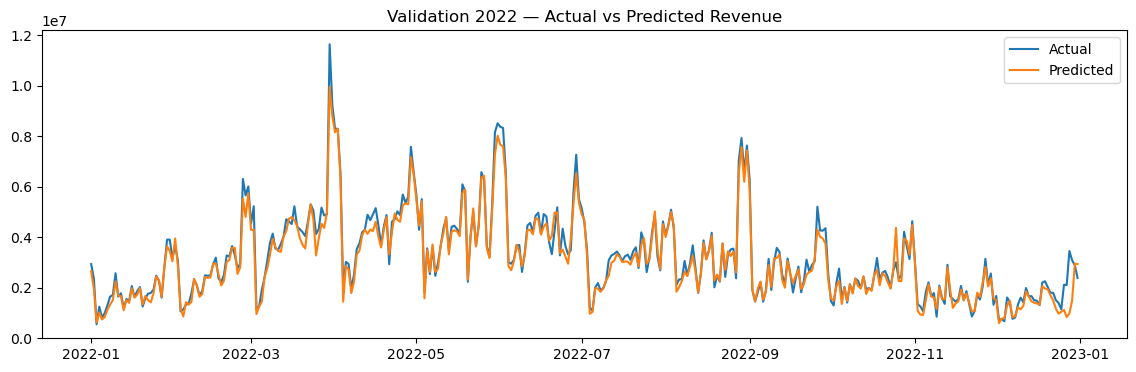

In [23]:
# Cell 21
plt.figure(figsize=(14,4))
plt.plot(val_df["Date"], y_val.values, label="Actual")
plt.plot(val_df["Date"], val_pred, label="Predicted")
plt.title("Validation 2022 — Actual vs Predicted Revenue")
plt.legend()
plt.show()

### 17.1. Phân tích lỗi dự báo

Bước này kiểm tra các ngày mô hình dự báo sai nhiều nhất. Mục tiêu là hiểu mô hình đang yếu ở loại ngày nào: ngày spike, cuối tuần, cuối tháng hay các giai đoạn có biến động bất thường.

Top 10 ngày dự báo sai nhiều nhất:


,Date,Revenue,Predicted,Error,Abs_Error,APE
3829,2022-12-28,3448729.20,9.748233e+05,2.473906e+06,2.473906e+06,0.717338
3556,2022-03-30,11643208.73,9.954229e+06,1.688980e+06,1.688980e+06,0.145061
3830,2022-12-29,3083944.33,1.479136e+06,1.604808e+06,1.604808e+06,0.520375
3765,2022-10-25,3003375.87,4.367074e+06,-1.363698e+06,1.363698e+06,0.454055
3828,2022-12-27,2100553.66,8.302189e+05,1.270335e+06,1.270335e+06,0.604762
3827,2022-12-26,2110830.12,1.118353e+06,9.924771e+05,9.924771e+05,0.470183
3528,2022-03-02,5221766.09,4.291303e+06,9.304630e+05,9.304630e+05,0.178189
3736,2022-09-26,5205389.57,4.302404e+06,9.029860e+05,9.029860e+05,0.173471
3617,2022-05-30,8158502.00,7.272395e+06,8.861067e+05,8.861067e+05,0.108611
3551,2022-03-25,4122489.22,3.272134e+06,8.503557e+05,8.503557e+05,0.206272


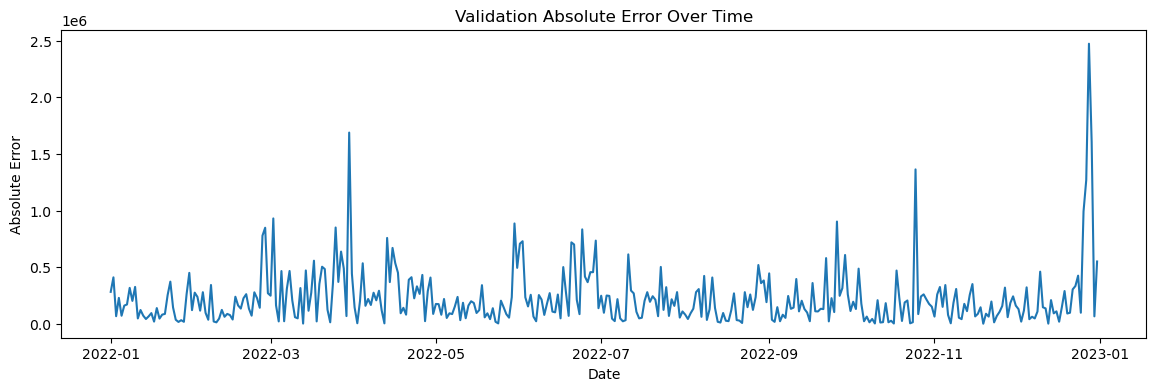

In [24]:
# Cell 22
error_df = val_df[["Date", "Revenue"]].copy()
error_df["Predicted"] = val_pred
error_df["Error"] = error_df["Revenue"] - error_df["Predicted"]
error_df["Abs_Error"] = error_df["Error"].abs()
error_df["APE"] = error_df["Abs_Error"] / error_df["Revenue"]

error_df = error_df.sort_values("Abs_Error", ascending=False)

print("Top 10 ngày dự báo sai nhiều nhất:")
display(error_df.head(10))

plt.figure(figsize=(14,4))
plt.plot(error_df.sort_values("Date")["Date"], error_df.sort_values("Date")["Abs_Error"])
plt.title("Validation Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.show()

### 18. Phân tích tầm quan trọng của đặc trưng

Bước này giúp hiểu mô hình đang dựa vào những yếu tố nào để đưa ra dự báo.

Thông thường các feature quan trọng sẽ bao gồm:
- lag_365 (cùng kỳ năm trước)
- rolling mean
- các biến calendar
- traffic và inventory

In [25]:
# Cell 23
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
60,delivered_orders,6736
61,gross_profit,4745
57,refund_amount,3984
58,lost_gmv,3889
65,profit_to_revenue,3432
63,discount_total,3265
64,refund_ratio,3108
56,bad_orders,2984
39,revenue_lag_1,2909
67,net_business_score,2896


### 19. Dự báo cho tập test bằng phương pháp recursive (nâng cao)

Do tập test không có giá trị Revenue thực tế, việc tạo lag và rolling phải dựa trên các giá trị dự báo trước đó.

Quy trình:
- dự báo từng ngày theo thứ tự thời gian
- cập nhật kết quả vào lịch sử
- sử dụng kết quả này để tạo feature cho ngày tiếp theo

Trong Phase 2, các feature bổ sung như momentum và growth cũng được tính trong quá trình recursive.

Phương pháp này mô phỏng đúng tình huống thực tế khi triển khai mô hình forecasting, tuy nhiên có thể tích lũy sai số theo thời gian.

In [26]:
# Cell 24
full_history = sales[["Date", "Revenue"]].copy()
full_history = full_history.sort_values("Date").reset_index(drop=True)

test_pred_rows = []
test_base = sample.sort_values("Date").reset_index(drop=True).copy()

for i in range(len(test_base)):
    row = test_base.iloc[i].copy()
    current_date = row["Date"]

    temp_hist = full_history.copy()

    def get_lag(days):
        target_date = current_date - pd.Timedelta(days=days)
        value = temp_hist.loc[temp_hist["Date"] == target_date, "Revenue"]
        if len(value) > 0:
            return value.values[0]
        return np.nan

    # Lag features
    row["revenue_lag_1"] = get_lag(1)
    row["revenue_lag_7"] = get_lag(7)
    row["revenue_lag_14"] = get_lag(14)
    row["revenue_lag_30"] = get_lag(30)
    row["revenue_lag_365"] = get_lag(365)

    hist_before = temp_hist[temp_hist["Date"] < current_date].sort_values("Date")

    # Rolling features
    row["revenue_roll_mean_7"] = hist_before["Revenue"].tail(7).mean()
    row["revenue_roll_mean_14"] = hist_before["Revenue"].tail(14).mean()
    row["revenue_roll_mean_30"] = hist_before["Revenue"].tail(30).mean()

    row["revenue_roll_std_7"] = hist_before["Revenue"].tail(7).std()
    row["revenue_roll_std_30"] = hist_before["Revenue"].tail(30).std()

    # Momentum features
    row["revenue_diff_1_7"] = row["revenue_lag_1"] - row["revenue_lag_7"]
    row["revenue_diff_7_30"] = row["revenue_lag_7"] - row["revenue_lag_30"]

    row["revenue_ratio_1_7"] = row["revenue_lag_1"] / (row["revenue_lag_7"] + 1)
    row["revenue_ratio_7_30"] = row["revenue_lag_7"] / (row["revenue_lag_30"] + 1)
    row["revenue_ratio_1_365"] = row["revenue_lag_1"] / (row["revenue_lag_365"] + 1)

    row["revenue_momentum_7_30"] = row["revenue_roll_mean_7"] / (row["revenue_roll_mean_30"] + 1)
    row["revenue_volatility_ratio"] = row["revenue_roll_std_7"] / (row["revenue_roll_std_30"] + 1)

    X_test_one = pd.DataFrame([row])[feature_cols]

    for col in feature_cols:
        if X_test_one[col].isnull().any():
            X_test_one[col] = X_test_one[col].fillna(model_df[col].median())

    pred = model.predict(X_test_one)[0]
    pred = max(pred, 0)

    test_pred_rows.append({
        "Date": current_date,
        "Revenue": pred
    })

    full_history = pd.concat([
        full_history,
        pd.DataFrame({"Date": [current_date], "Revenue": [pred]})
    ], ignore_index=True)

test_revenue_pred = pd.DataFrame(test_pred_rows)
test_revenue_pred.head()

,Date,Revenue
0,2023-01-01,3.577830e+06
1,2023-01-02,1.862839e+06
2,2023-01-03,1.334939e+06
3,2023-01-04,1.437249e+06
4,2023-01-05,1.552601e+06


### 20. Ước lượng COGS từ Revenue

Trong Phase 1, COGS được tính dựa trên tỷ lệ lịch sử giữa COGS và Revenue.

Sau đó áp dụng ràng buộc:
COGS < Revenue

Điều này đảm bảo kết quả hợp lý về mặt kinh doanh.

In [27]:
# Cell 25
cogs_ratio = (sales["COGS"] / sales["Revenue"]).median()
print("COGS ratio:", cogs_ratio)

test_revenue_pred["COGS"] = test_revenue_pred["Revenue"] * cogs_ratio

# đảm bảo logic COGS < Revenue
test_revenue_pred["COGS"] = np.minimum(
    test_revenue_pred["COGS"],
    test_revenue_pred["Revenue"] * 0.95
)

COGS ratio: 0.8216995431091048


### 21. Tạo file submission

File submission bao gồm 3 cột:
- Date
- Revenue
- COGS

Thứ tự và định dạng cột phải giữ nguyên theo sample_submission để đảm bảo đúng format yêu cầu của hệ thống chấm điểm.

In [28]:
# Cell 26
submission = sample[["Date"]].merge(test_revenue_pred, on="Date", how="left")

submission["Revenue"] = submission["Revenue"].clip(lower=0)
submission["COGS"] = submission["COGS"].clip(lower=0)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

print(submission.head())
print(submission.shape)
print(submission.isnull().sum())

submission.to_csv("submission_v2.csv", index=False)

         Date       Revenue          COGS
0  2023-01-01  3.577830e+06  2.939901e+06
1  2023-01-02  1.862839e+06  1.530694e+06
2  2023-01-03  1.334939e+06  1.096919e+06
3  2023-01-04  1.437249e+06  1.180987e+06
4  2023-01-05  1.552601e+06  1.275771e+06
(548, 3)
Date       0
Revenue    0
COGS       0
dtype: int64


### 22. Kiểm tra file submission

Trước khi nộp cần đảm bảo:
- Không có giá trị thiếu
- Số dòng đúng
- Không có giá trị âm
- COGS luôn nhỏ hơn Revenue

Các bước này giúp tránh lỗi khi upload lên hệ thống.

In [29]:
# Cell 27
sample_check = pd.read_csv("sample_submission.csv", usecols=["Date"])

assert len(submission) == len(sample_check), "Submission row count does not match sample_submission."
assert submission.isnull().sum().sum() == 0, "Submission contains missing values."
assert list(submission.columns) == ["Date", "Revenue", "COGS"], "Submission columns are incorrect."
assert (submission["Revenue"] >= 0).all(), "Revenue contains negative values."
assert (submission["COGS"] >= 0).all(), "COGS contains negative values."
assert (submission["COGS"] < submission["Revenue"]).all(), "Some COGS values are not lower than Revenue."

print("Submission validation passed.")

Submission validation passed.


### 23. Tổng kết Phase 1

Phase 1 xây dựng một pipeline dự báo hoàn chỉnh dựa trên:
- dữ liệu lịch sử
- đặc trưng thời gian
- tín hiệu từ traffic và inventory

So với baseline, mô hình này đã chuyển từ dự báo theo pattern sang dự báo dựa trên yếu tố kinh doanh.

Kết quả đầu ra:
- mô hình LightGBM
- các chỉ số đánh giá
- biểu đồ validation
- file submission_v1.csv

Đây là nền tảng để tiếp tục cải tiến ở các phase tiếp theo.

### 24. Tổng kết Phase 2

Trong Phase 2, pipeline dự báo đã được nâng cấp từ mô hình cơ bản sang mô hình có khả năng học sâu hơn về hành vi dữ liệu và logic kinh doanh.

Các cải tiến chính bao gồm:

- Mở rộng đặc trưng thời gian (calendar nâng cao và cyclical encoding)
- Bổ sung đặc trưng từ web traffic phản ánh chất lượng truy cập
- Xây dựng đặc trưng từ inventory thể hiện khả năng cung ứng
- Tạo các đặc trưng động lực (momentum) và tăng trưởng từ doanh thu
- Tinh chỉnh mô hình LightGBM để học tốt hơn các quan hệ phi tuyến
- Phân tích lỗi dự báo để hiểu điểm yếu của mô hình

Kết quả đạt được:
- MAE giảm so với Phase 1
- RMSE giảm, cho thấy cải thiện trong việc xử lý các ngày có biến động lớn
- R² tăng lên trên 0.8, thể hiện mô hình đã giải thích tốt hơn biến động doanh thu

Nhìn chung, mô hình Phase 2 đã:
- Nắm bắt tốt xu hướng (trend)
- Học được tính mùa vụ (seasonality)
- Phản ánh được động lực ngắn hạn (momentum)
- Bắt đầu tích hợp các yếu tố kinh doanh (traffic, inventory)

Tuy nhiên, mô hình vẫn còn hạn chế trong việc dự báo các ngày có biến động đột biến (spike), thường liên quan đến các yếu tố như khuyến mãi hoặc sự kiện đặc biệt.

Định hướng cho Phase 3:
- Bổ sung các đặc trưng liên quan đến promotion và event
- Cải thiện khả năng dự báo các ngày có spike
- Tiếp tục tối ưu mô hình và feature engineering dựa trên kết quả phân tích lỗi

Kết quả của Phase 2 là nền tảng quan trọng để phát triển mô hình forecasting có tính cạnh tranh cao trong các bước tiếp theo.